In [2]:
import os
import glob
from dotenv import load_dotenv
from pathlib import Path
import gradio as gr
from openai import OpenAI

In [4]:
load_dotenv(override=True)

openai_api_key = os.getenv("OPENAI_API_KEY")
google_api_key = os.getenv("GOOGLE_API_KEY")

if openai_api_key.startswith("sk-proj"):
    print("Valid OpenAI API Key")
else:
    print("OpenAI API Key not found or invalid")

if google_api_key.startswith("AI"):
    print("Valid Google API Key")
else:
    print("Google API Key not found or invalid")

Valid OpenAI API Key
Valid Google API Key


In [6]:
openai=OpenAI()

GPT_MODEL = 'gpt-4.1-nano'
GEMINI_MODEL = 'gemini-2.5-flash-lite'

google_url = "https://generativelanguage.googleapis.com/v1beta/openai/"

gemini = OpenAI(base_url=google_url, api_key=google_api_key)



Knowledge base folder contains 4 directories of MD folders. This is all synthetic data - you cant tell as all the reports are unrealistically optimistic about anything due to the training of the LLM that made the data 

In [ ]:
#read employee data into directory

knowledge = {}

filenames = glob.glob("knowledge-base/employees/*") # * = wildcard for all files in employees

for filename in filenames:
    name = Path(filename).stem.split(" ")[-1] #takes last name
    with open(filename, 'r',  encoding='utf-8') as f:
        knowledge[name.lower()] = f.read()

In [24]:
#read product data into directory

filenames = glob.glob("knowledge-base/products/*")

for filename in filenames:
    name = Path(filename).stem
    with open(filename, "r", encoding="utf-8") as f:
        knowledge[name.lower()] = f.read()

In [25]:
knowledge['kim']

'# HR Record\n\n# David Kim\n\n## Summary\n- **Date of Birth:** September 22, 1992\n- **Job Title:** DevOps Engineer\n- **Location:** New York, New York\n- **Current Salary:** $118,000\n\n## Insurellm Career Progression\n- **August 2021 - Present:** DevOps Engineer\n  - Manages AWS infrastructure for all Insurellm products\n  - Implemented CI/CD pipelines reducing deployment time by 60%\n  - Led migration to Kubernetes, improving system scalability and reliability\n\n- **March 2019 - July 2021:** Junior DevOps Engineer\n  - Assisted with infrastructure monitoring and incident response\n  - Automated manual deployment processes using Jenkins and Terraform\n  - Supported senior engineers in cloud infrastructure management\n\n- **June 2017 - February 2019:** Systems Administrator at CloudFirst Solutions\n  - Maintained Linux servers and network infrastructure\n  - Provided technical support for cloud-based services\n\n## Annual Performance History\n- **2023:** Rating: 4.5/5\n  *Strong per

In [26]:
SYSTEM_PREFIX = """  
You represent Insurellm, the Insurance Tech company.
You are an expert in answering questions about Insurellm; its employees and its products.
You are provided with additional context that might be relevant to the user's question.
Give brief, accurate answers. If you don't know the answer, say so.

Relevant context:
"""

## Very Basic/Fake RAG

In [ ]:
def get_relevant_context_simple(message):
    text = ''.join(ch for ch in message if ch.isalpha() or ch.isspace()) # strip punctuation or spaces (advanced would be regex)
    words = text.lower().split() # convert to lower case and split words
    relevant_context=[] # empty list
    for word in words:
        if word in knowledge:
            relevant_context.append(knowledge[word]) #search for word in knowledge then append to our list
    return relevant_context 

In [31]:
def get_relevant_context(message):
    text = ''.join(ch for ch in message if ch.isalpha() or ch.isspace())
    words = text.lower().split()
    return [knowledge[word] for word in words if word in knowledge]   #list comprehension (read backwards)

get_relevant_context("Who is lancaster and who and who is carLLM")

["# Avery Lancaster\n\n## Summary\n- **Date of Birth**: March 15, 1985\n- **Job Title**: Co-Founder & Chief Executive Officer (CEO)\n- **Location**: San Francisco, California\n- **Current Salary**: $225,000  \n\n## Insurellm Career Progression\n- **2015 - Present**: Co-Founder & CEO  \n  Avery Lancaster co-founded Insurellm in 2015 and has since guided the company to its current position as a leading Insurance Tech provider. Avery is known for her innovative leadership strategies and risk management expertise that have catapulted the company into the mainstream insurance market.  \n\n- **2013 - 2015**: Senior Product Manager at Innovate Insurance Solutions  \n  Before launching Insurellm, Avery was a leading Senior Product Manager at Innovate Insurance Solutions, where she developed groundbreaking insurance products aimed at the tech sector.  \n\n- **2010 - 2013**: Business Analyst at Edge Analytics  \n  Prior to joining Innovate, Avery worked as a Business Analyst, focusing on market 

## AI Enabled

In [ ]:
def additional_context(message):
    relevant_context = get_relevant_context(message)
    if not relevant_context:
        result = "There is no additional context relevant to the users question."
    else:
        result = "The following additional context might be relevant in answering the users question:\n\n"
        result += "\n\n".join(relevant_context)
    return result



In [35]:
print(additional_context("Who is Avery Lancaster?"))

The following additional context misght be relevant in answering the users question:

# Avery Lancaster

## Summary
- **Date of Birth**: March 15, 1985
- **Job Title**: Co-Founder & Chief Executive Officer (CEO)
- **Location**: San Francisco, California
- **Current Salary**: $225,000  

## Insurellm Career Progression
- **2015 - Present**: Co-Founder & CEO  
  Avery Lancaster co-founded Insurellm in 2015 and has since guided the company to its current position as a leading Insurance Tech provider. Avery is known for her innovative leadership strategies and risk management expertise that have catapulted the company into the mainstream insurance market.  

- **2013 - 2015**: Senior Product Manager at Innovate Insurance Solutions  
  Before launching Insurellm, Avery was a leading Senior Product Manager at Innovate Insurance Solutions, where she developed groundbreaking insurance products aimed at the tech sector.  

- **2010 - 2013**: Business Analyst at Edge Analytics  
  Prior to joini

In [ ]:
def chat(message, history):
    system_message = SYSTEM_PREFIX + additional_context(message)
    messages = [{"role":"system", "content": system_message}] + history + [{"role":"user", "content": message}] #history of chat may influence response
    #in a fresh chat asking about avery would return nothing as we have hard coded last name search - fuzzy matching can be a solution
    response = openai.chat.completions.create(model=GPT_MODEL, messages=messages)
    return response.choices[0].message.content

In [37]:
# launch in gradio
view = gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7873
* To create a public link, set `share=True` in `launch()`.


## Vector Embeddings & Coding LLMs

Auto-Regressive - predict the next token i.e., ChatGPT, Gemini.

Auto-Encoding/Embedding - 1 output that reflects a whole input i.e., Token for a group of characters
> * Applications include sentiment analysis and classification.
> * Calculate Vector Embeddings
> * Examples: BERT (Google), OpenAIEmbeddings

LLMs are mathematical models so we need to assign values to represent these - tokens


Vector - Mathematically represent the meaning of an input (Word, Character, Document, or something abstract like a job)
> * Have 00's/000's dimensions
> * Represent an understanding so similar inputs are close to each other
> * Word2vec (predecessor of LLM used in NLP) simple way to map a single word to a vector i.e., Vecotor math means we can use the vectors of words to identify other words of the correct meaning so King - Man + Woman = Queen or Paris - France + England = London. We can now do this will full paragraphs or documents in vector space
> * nowadays we can use euclidean/cosine similarity to establish distance

## RAG

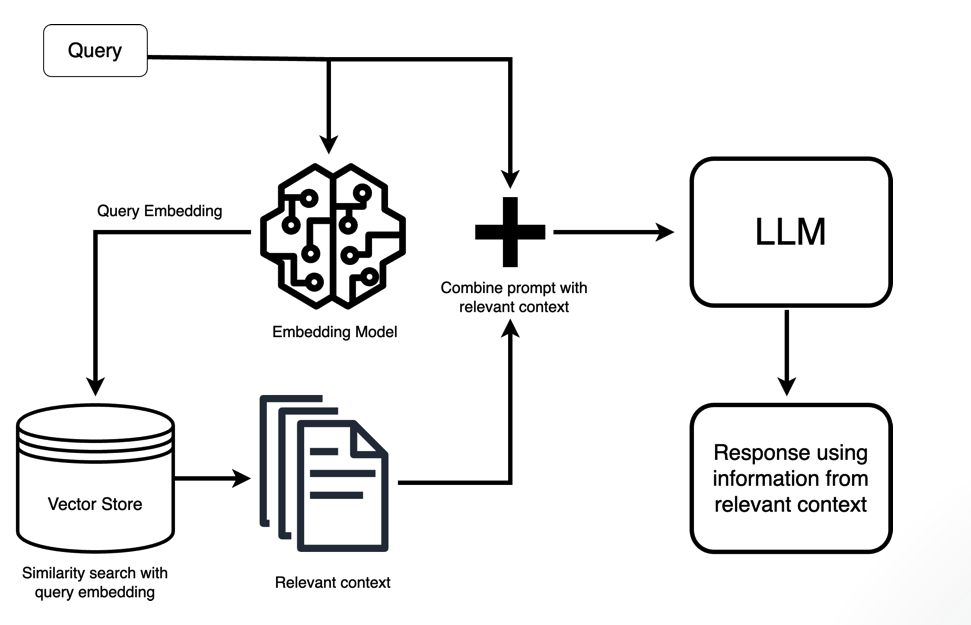
Question -> Vectorise -> Search data store for information close to Question vector -> Prompt = Question + additional info -> LLM _> Response
